In [2]:
import numpy as np
import copy
from time import time
import pickle
from scipy.optimize import minimize
import gfapy
import networkx as nx
import re

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.passes.routing.commuting_2q_gate_routing import SwapStrategy

from sympy import Poly
from sympy import symbols, srepr, Symbol

from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeFez

In [83]:
filename = '/nfs/users/nfs_j/jc59/quantumwork/pangenome/data/test_N8_W4.gfa'
gfa = gfapy.Gfa.from_file(filename, vlevel=0)


In [84]:
graph = nx.DiGraph()
for index, segment_line in enumerate(gfa.segments):
    graph.add_node(f'{segment_line.name}_+', weight=segment_line.SC, start=segment_line.st)
    graph.add_node(f'{segment_line.name}_-', weight=segment_line.SC, start=segment_line.st)
for edge_line in gfa.edges:
    v1 = edge_line.sid1
    v2 = edge_line.sid2
    graph.add_edges_from([
        (f'{v1.name}_{v1.orient}', f'{v2.name}_{v2.orient}'),
    ])
    v1.invert()
    v2.invert()
    graph.add_edges_from([
        (f'{v2.name}_{v2.orient}', f'{v1.name}_{v1.orient}'),
    ])

nodes = list(graph.nodes)
N = len(nodes)
n = int(np.ceil(np.log2(N+1)))
total_weight = int(sum(graph.nodes[node]["weight"] for node in nodes) / 2)
T = int(1.1 * total_weight)

In [85]:
nodes

['u0_+',
 'u0_-',
 'u1_+',
 'u1_-',
 'u2_+',
 'u2_-',
 'u3_+',
 'u3_-',
 'u4_+',
 'u4_-',
 'u5_+',
 'u5_-',
 'u6_+',
 'u6_-',
 'u7_+',
 'u7_-']

In [86]:
class Binary(Symbol):
    def _eval_power(self, other):
        return self

In [87]:
x = [[Binary(f'x[{t}][{i}]') for i in range(n)] for t in range(T)]
x

[[x[0][0], x[0][1], x[0][2], x[0][3], x[0][4]],
 [x[1][0], x[1][1], x[1][2], x[1][3], x[1][4]],
 [x[2][0], x[2][1], x[2][2], x[2][3], x[2][4]],
 [x[3][0], x[3][1], x[3][2], x[3][3], x[3][4]]]

In [88]:
def bin_rep(k):
    return [int(x) for x in np.binary_repr(k, n)[::-1]]

In [89]:
constraint: Poly = sum([
    1 - sum([
        np.prod([
            1 - x[t][k] - bin_rep(i)[k] + 2 * x[t][k] * bin_rep(i)[k]
        for k in range(n)]) * sum([
            np.prod([
                1 - x[t+1][k] - bin_rep(j)[k] + 2 * x[t+1][k] * bin_rep(j)[k]
            for k in range(n)])
        for j in [nodes.index(nbr) for nbr in graph.neighbors(nodes[i])]])
    for i in range(N)])
for t in range(T-1)])

In [90]:
obj: Poly = sum([
    (
        sum([
            np.prod([
                1 - x[t][k] - bin_rep(i)[k] + 2 * x[t][k] * bin_rep(i)[k]
            for k in range(n)])
            + np.prod([
                1 - x[t][k] - bin_rep(i+1)[k] + 2 * x[t][k] * bin_rep(i+1)[k]
            for k in range(n)])
        for t in range(T)])
        - graph.nodes[nodes[i]]["weight"]
    ) ** 2
for i in range(0,N,2)])

In [92]:
lamda = 10
total = lamda * constraint + obj
# total = Poly(total, domain='ZZ')
# total

In [93]:
Z = [Binary(f"Z[{i}]") for i in range(n*T)]


In [107]:
ising = total.subs(zip([item for row in x for item in row], [0.5 - z/2 for z in Z]))

ising.as_expr()

-10*(0.5 - Z[0]/2)*(0.5 - Z[1]/2)*(0.5 - Z[2]/2)*(0.5 - Z[3]/2)*(Z[4]/2 + 0.5)*((0.5 - Z[5]/2)*(0.5 - Z[6]/2)*(0.5 - Z[8]/2)*(Z[7]/2 + 0.5)*(Z[9]/2 + 0.5) + (0.5 - Z[5]/2)*(0.5 - Z[7]/2)*(0.5 - Z[8]/2)*(Z[6]/2 + 0.5)*(Z[9]/2 + 0.5) + (0.5 - Z[5]/2)*(0.5 - Z[7]/2)*(Z[6]/2 + 0.5)*(Z[8]/2 + 0.5)*(Z[9]/2 + 0.5) + (0.5 - Z[5]/2)*(0.5 - Z[8]/2)*(Z[6]/2 + 0.5)*(Z[7]/2 + 0.5)*(Z[9]/2 + 0.5)) - 10*(0.5 - Z[0]/2)*(0.5 - Z[1]/2)*(0.5 - Z[2]/2)*(Z[3]/2 + 0.5)*(Z[4]/2 + 0.5)*((0.5 - Z[5]/2)*(0.5 - Z[6]/2)*(Z[7]/2 + 0.5)*(Z[8]/2 + 0.5)*(Z[9]/2 + 0.5) + (0.5 - Z[5]/2)*(0.5 - Z[7]/2)*(Z[6]/2 + 0.5)*(Z[8]/2 + 0.5)*(Z[9]/2 + 0.5)) - 10*(0.5 - Z[0]/2)*(0.5 - Z[1]/2)*(0.5 - Z[3]/2)*(Z[2]/2 + 0.5)*(Z[4]/2 + 0.5)*((0.5 - Z[5]/2)*(0.5 - Z[6]/2)*(0.5 - Z[7]/2)*(Z[8]/2 + 0.5)*(Z[9]/2 + 0.5) + (0.5 - Z[5]/2)*(0.5 - Z[8]/2)*(Z[6]/2 + 0.5)*(Z[7]/2 + 0.5)*(Z[9]/2 + 0.5)) - 10*(0.5 - Z[0]/2)*(0.5 - Z[1]/2)*(0.5 - Z[5]/2)*(Z[2]/2 + 0.5)*(Z[3]/2 + 0.5)*(Z[4]/2 + 0.5)*(Z[6]/2 + 0.5)*(Z[7]/2 + 0.5)*(Z[8]/2 + 0.5)*(Z[9]

In [108]:
ising = Poly(ising, Z)
ising.as_expr()

0.0390625*Z[0]*Z[1]*Z[2]*Z[3]*Z[4]*Z[5]*Z[6]*Z[7]*Z[8]*Z[9] + 0.0390625*Z[0]*Z[1]*Z[2]*Z[3]*Z[4]*Z[5]*Z[6]*Z[7]*Z[8] + 0.0390625*Z[0]*Z[1]*Z[2]*Z[3]*Z[4]*Z[5]*Z[6]*Z[7]*Z[9] + 0.0390625*Z[0]*Z[1]*Z[2]*Z[3]*Z[4]*Z[5]*Z[6]*Z[7] + 0.0390625*Z[0]*Z[1]*Z[2]*Z[3]*Z[4]*Z[5]*Z[6]*Z[8]*Z[9] + 0.0390625*Z[0]*Z[1]*Z[2]*Z[3]*Z[4]*Z[5]*Z[6]*Z[8] + 0.0390625*Z[0]*Z[1]*Z[2]*Z[3]*Z[4]*Z[5]*Z[8]*Z[9] + 0.0390625*Z[0]*Z[1]*Z[2]*Z[3]*Z[4]*Z[5]*Z[8] + 0.0390625*Z[0]*Z[1]*Z[2]*Z[3]*Z[4]*Z[6]*Z[7]*Z[9] + 0.0390625*Z[0]*Z[1]*Z[2]*Z[3]*Z[4]*Z[6]*Z[7] - 0.078125*Z[0]*Z[1]*Z[2]*Z[3]*Z[4]*Z[6]*Z[9] - 0.078125*Z[0]*Z[1]*Z[2]*Z[3]*Z[4]*Z[6] - 0.078125*Z[0]*Z[1]*Z[2]*Z[3]*Z[4]*Z[7]*Z[8]*Z[9] - 0.078125*Z[0]*Z[1]*Z[2]*Z[3]*Z[4]*Z[7]*Z[8] - 0.0390625*Z[0]*Z[1]*Z[2]*Z[3]*Z[4]*Z[7]*Z[9] - 0.0390625*Z[0]*Z[1]*Z[2]*Z[3]*Z[4]*Z[7] + 0.0390625*Z[0]*Z[1]*Z[2]*Z[3]*Z[4]*Z[8]*Z[9] + 0.0390625*Z[0]*Z[1]*Z[2]*Z[3]*Z[4]*Z[8] - 0.0390625*Z[0]*Z[1]*Z[2]*Z[3]*Z[4]*Z[9] - 0.0390625*Z[0]*Z[1]*Z[2]*Z[3]*Z[4] + 0.0390625*Z[0]*Z[1]*Z[2]

In [42]:
# ising = Poly(ising, Z, domain='QQ')
# ising = ising.simplify()
expr = ising.as_expr()


In [46]:
def monomial_to_pauli(monomial):
    indices = [int(re.search(r'[0-9]+', atom.name).group(0)) for atom in monomial.atoms()]
    pauli_str = ['I'] * n * T
    for i in indices:
        pauli_str[i] = 'Z'
    return ''.join(pauli_str)

In [47]:
hamiltonian = SparsePauliOp('I'*n*T, expr.as_coefficients_dict()[1])
for (monomial, coeff) in expr.as_coefficients_dict().items():
    if monomial == 1:
        continue
    hamiltonian += SparsePauliOp(monomial_to_pauli(monomial), coeff)

In [48]:
hamiltonian = hamiltonian.sort(weight=True)

In [ ]:
qc = QAOAAnsatz(
    cost_operator=hamiltonian,
    reps = 1,
    flatten=True
)

In [ ]:
# qc.draw(fold=-1)

In [ ]:
def two_qubit_count(qc):
    return qc.count_ops().get("cz", 0) + qc.count_ops().get("rzz", 0) + qc.count_ops().get("cx", 0)

def depth(qc):
    return qc.depth(lambda instr: len(instr.qubits) > 1)

In [ ]:
print(two_qubit_count(qc))
print(depth(qc))
print(qc.num_qubits)

In [ ]:
backend_options = dict(
    method='statevector',
    # device='GPU',
    # cuStateVec_enable=True,
    # blocking_enable=True,
    # blocking_qubits=24,
    # batched_shots_gpu_max_qubits=24,
    precision='single'
)
fake_fez = FakeFez()
backend = AerSimulator.from_backend(fake_fez, **backend_options)

In [ ]:
tqc = transpile(qc, backend, optimization_level=3)

In [ ]:
print(two_qubit_count(tqc))
print(depth(tqc))

In [ ]:
def circuit_to_graph(qc: QuantumCircuit, parameter) -> nx.Graph:
    """"QAOA Cost operator as a circuit to a graph"""
    print(parameter)
    qreg = qc.qregs[0]
    graph, edges = nx.Graph(), []
    graph.add_nodes_from(range(len(qreg)))
    seen_edges = set()

    for inst in qc.data:
        iop = inst.operation
        if len(iop.params) == 0 or parameter not in iop.params[0].parameters:
            continue

        if len(inst.qubits) == 1:
            edge = (qreg.index(inst.qubits[0]), qreg.index(inst.qubits[0]))
        elif len(inst.qubits) == 2:
            edge = (qreg.index(inst.qubits[0]), qreg.index(inst.qubits[1]))
        else:
            raise ValueError('Too many qubits in instruction')
        
        if edge in seen_edges:
            raise ValueError(f'Circuit contains edge {edge} multiple times')

        print(edge)
        seen_edges.add(edge)
        seen_edges.add(edge[::-1])

        param_expression = copy.deepcopy(iop.params[0])
        param_expression = param_expression.assign(next(iter(param_expression.parameters)), 1)
        weight = float(param_expression) / 2.0
        print(weight)
        edges.append((edge[0], edge[1], weight))

    graph.add_weighted_edges_from(edges)
    return graph

In [3]:
# res = np.array([
#     [ 12, 429, 779],
#     [ 16, 3150, 4668],
#     [ 20, 11790, 15337],
#     [ 24, 6731, 9962],
#     [30, 25588, 32093],
#     [30, 35061, 42029],
#     [35, 45577, 55537]
# ])

res = np.array([
    [ 12, 429, 779],
    [ 16, 3150, 4668],
    [ 20, 11790, 15337],
    # [ 24, 6731, 9962],
    [30, 25588, 32093],
    [30, 35061, 42029],
    [35, 45577, 55537],
    [66, 88126, 112677]
])


In [4]:
from matplotlib import pyplot as plt

In [14]:
grid = np.linspace(res[0, 0], res[-1, 0], 20)

p_depth_pre = np.polynomial.polynomial.Polynomial.fit(res[:, 0], res[:, 1], 1)
p_depth_post = np.polynomial.polynomial.Polynomial.fit(res[:, 0], res[:, 2], 1)

In [15]:
p_depth_pre(100)

np.float64(147800.8346827617)

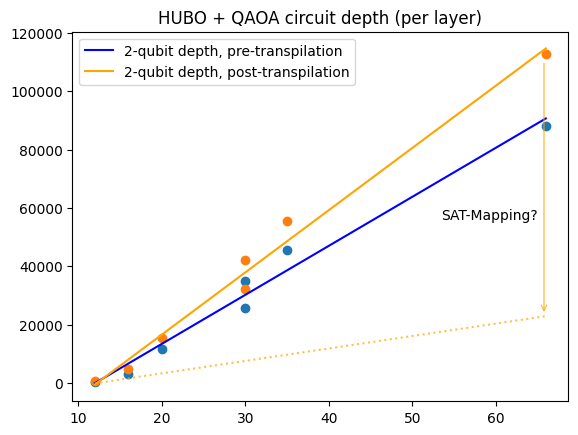

In [43]:
fig, ax = plt.subplots()
ax.scatter(res[:, 0], res[:, 1])
ax.scatter(res[:,0], res[:,2])
ax.plot(grid, p_depth_pre(grid), color='b', linestyle='-', label='2-qubit depth, pre-transpilation')
ax.plot(grid, p_depth_post(grid), color='orange', linestyle='-', label='2-qubit depth, post-transpilation')
ax.annotate("", xytext=(0.85, 0.78), xy=(0.85, 0.25), xycoords='figure fraction', arrowprops=dict(arrowstyle="->", color='orange',alpha=0.7))
ax.annotate("SAT-Mapping?", xytext=(0.69, 0.45), xy=(0.69, 0.45), xycoords='figure fraction')
ax.legend()
ax.plot(grid, p_depth_post(grid)/5, color='orange', alpha=0.7, linestyle=':', label='2-qubit depth, post-transpilation')
ax.set_title('HUBO + QAOA circuit depth (per layer)')
fig.show()